# 07 — Evaluation

**This notebook answers evaluator points 1, 2, 3, 4, 6, 7 and 8 in one place.**

| Point | Where it is answered |
|---|---|
| 1. Precision | section 2 |
| 2. Recall | section 2 |
| 3. F1-score | section 2 |
| 4. False-negative rate | section 2, reported explicitly as "we miss X%" |
| 6. Forecast horizons 1 h / 3 h / 6 h | every table is split by horizon |
| 7. Time-based train/test split | section 1 — rolling origin, four folds |
| 8. False-positive / false-negative analysis | sections 5 and 6 |

**Three principles this notebook sticks to.**

1. **No accuracy.** At a base rate near 1 in 4,000, predicting "no flood" always gives
   99.97% accuracy. The number is worse than useless — it is actively misleading.
2. **Every headline gets decomposed.** Overall recall is always shown next to onset recall,
   because the gap between them is the difference between forecasting and monitoring.
3. **Thresholds come from validation, never from test.** Tuning a cut-off on the data you
   report is how honest people accidentally overstate results by ten points.

In [1]:
import sys, pathlib
# Make the shared library importable no matter where Jupyter was started from.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "config" / "config.yaml").is_file())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

from bkkflood import CFG, PATHS
print("project root:", ROOT)
print("config version:", CFG["project"]["version"])
import json
import matplotlib.pyplot as plt
from bkkflood.metrics import (classification_metrics, decompose_by_onset, threshold_sweep,
                              pick_threshold, per_station_breakdown, extract_cases,
                              event_scores, coverage)
from bkkflood.modeling import (load_model, persistence_score, hybrid_score,
                               fit_calibrator, calibration_table)
from bkkflood.splits import rolling_origin_folds, split_frame, summarise_folds, holdout_is_sealed
from bkkflood.features import feature_columns, load_training_years
from bkkflood.labels import find_events_frame

PRIMARY = CFG["flood_event"]["primary_tier_cm"]
HORIZONS = CFG["forecast"]["horizons_h"]

project root: /Users/pritimmondal/Projects/bkk-flood-forecast
config version: 2.0.0


## 1. The evaluation protocol, stated before any numbers appear

Say what you did before you say how well it went. A reader who disagrees with the protocol
can stop reading here rather than being persuaded by numbers produced under rules they
would have rejected.

In [2]:
protocol = {
    "split": "rolling origin, chronological, no shuffling",
    "folds": [f.describe() for f in rolling_origin_folds()],
    "embargo_hours": CFG["splits"]["rolling_origin"]["embargo_hours"],
    "threshold_selection": "validation year only, then frozen for test",
    "primary_tier_cm": PRIMARY,
    "horizons_h": HORIZONS,
    "flood_event": CFG["flood_event"],
    "final_holdout_sealed": holdout_is_sealed(),
}
print(json.dumps(protocol, indent=2, default=str))

if not holdout_is_sealed():
    print("\nNOTE: the final holdout has already been opened by an earlier version of "
          "this project.\nRolling-origin folds are therefore the headline evidence, and "
          "any number quoted\nfrom the holdout year must be labelled as reused.")

{
  "split": "rolling origin, chronological, no shuffling",
  "folds": [
    "fold1_test2022: train 2019-2020 -> val 2021 -> test 2022",
    "fold2_test2023: train 2019-2021 -> val 2022 -> test 2023",
    "fold3_test2024: train 2019-2022 -> val 2023 -> test 2024",
    "fold4_test2025: train 2019-2023 -> val 2024 -> test 2025"
  ],
  "embargo_hours": 24,
  "threshold_selection": "validation year only, then frozen for test",
  "primary_tier_cm": 15,
  "horizons_h": [
    1,
    3,
    6
  ],
  "flood_event": {
    "tiers_cm": {
      "nuisance": 5,
      "advisory": 15,
      "severe": 30
    },
    "primary_tier_cm": 15,
    "persistence_readings": 2,
    "event_merge_gap_minutes": 60,
    "min_event_minutes": 10,
    "onset_definition": "depth_now_below_tier"
  },
  "final_holdout_sealed": false
}

NOTE: the final holdout has already been opened by an earlier version of this project.
Rolling-origin folds are therefore the headline evidence, and any number quoted
from the holdout year m

In [3]:
# Load per fold, not all at once — see the memory note in notebook 04.
from bkkflood.data import load_years, feature_list, available_years

YEARS = available_years()
FEATURES = feature_list()
print(f"years built: {YEARS}")
print(f"{len(FEATURES)} features")

years built: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
50 features


## 2. The headline table

Precision, recall, F1, F2 and the false-negative rate, for every tier and horizon, averaged
across folds with the spread shown.

In [4]:
results_path = PATHS.reports / "lightgbm_fold_results.csv"
if results_path.exists():
    folds_df = pd.read_csv(results_path)
else:
    folds_df = pd.DataFrame()
    print("Run notebook 04 first.")

if len(folds_df):
    summary = summarise_folds(
        folds_df.to_dict("records"),
        metric_cols=["precision", "recall", "f1", "f2", "false_negative_rate",
                     "pr_auc", "onset_recall"],
        group_cols=["target", "horizon_h"])
    show = summary[["target", "horizon_h", "recall_mean", "recall_std",
                    "precision_mean", "f1_mean", "f2_mean",
                    "false_negative_rate_mean", "onset_recall_mean"]].round(3)
    display(show)

,target,horizon_h,recall_mean,recall_std,precision_mean,f1_mean,f2_mean,false_negative_rate_mean,onset_recall_mean
0,ge15,1,0.707,0.059,0.054,0.099,0.201,0.293,0.426
1,ge15,3,0.385,0.066,0.063,0.107,0.187,0.615,0.179
2,ge15,6,0.235,0.065,0.062,0.097,0.148,0.765,0.105
3,ge30,1,0.557,0.174,0.522,0.427,0.401,0.443,0.143
4,ge30,3,0.347,0.092,0.262,0.206,0.216,0.653,0.119
5,ge30,6,0.292,0.129,0.009,0.018,0.041,0.708,0.171
6,ge5,1,0.612,0.046,0.154,0.244,0.379,0.388,0.249
7,ge5,3,0.312,0.055,0.163,0.211,0.260,0.688,0.088
8,ge5,6,0.189,0.040,0.160,0.169,0.179,0.811,0.055


In [5]:
# The same numbers written the way a person would say them out loud.
if len(folds_df):
    primary = folds_df[folds_df["target"] == f"ge{PRIMARY}"]
    print(f"At the {PRIMARY} cm tier, averaged over "
          f"{primary['fold'].nunique()} independent test years:\n")
    for horizon in HORIZONS:
        sub = primary[primary["horizon_h"] == horizon]
        if sub.empty:
            continue
        r, p = sub["recall"].mean(), sub["precision"].mean()
        onset = sub["onset_recall"].mean() if "onset_recall" in sub else float("nan")
        print(f"  {horizon}h ahead:")
        print(f"     catches {r:.0%} of flood rows, misses {1 - r:.0%}")
        print(f"     {p:.0%} of alarms are real -> about "
              f"{(1 - p) / max(p, 1e-9):.1f} false alarms per true one")
        print(f"     on rows that were NOT already flooded, catches {onset:.0%}")
        print(f"     recall range across years: {sub['recall'].min():.2f} "
              f"to {sub['recall'].max():.2f}\n")

At the 15 cm tier, averaged over 4 independent test years:

  1h ahead:
     catches 71% of flood rows, misses 29%
     5% of alarms are real -> about 17.5 false alarms per true one
     on rows that were NOT already flooded, catches 43%
     recall range across years: 0.64 to 0.78

  3h ahead:
     catches 38% of flood rows, misses 62%
     6% of alarms are real -> about 15.0 false alarms per true one
     on rows that were NOT already flooded, catches 18%
     recall range across years: 0.30 to 0.46

  6h ahead:
     catches 23% of flood rows, misses 77%
     6% of alarms are real -> about 15.0 false alarms per true one
     on rows that were NOT already flooded, catches 10%
     recall range across years: 0.14 to 0.29



**On the recall range.** A metric that swings from 0.18 to 0.44 across years should
never be summarised as "0.31" without that range beside it. The swing is not noise in the
model — it is the difference between a wet year and a dry one, and an operator planning
staffing needs to know it exists.

## 3. The false-negative rate, stated as a miss rate

FNR is `1 - recall`, but the two phrasings land completely differently on a reader. "Recall
0.55" sounds like a result. "We miss 45% of floods" is the same fact and is the one that
prompts the right follow-up question, which is: *which* 45%?

In [6]:
if len(folds_df):
    fnr = (folds_df.groupby(["target", "horizon_h"])["false_negative_rate"]
                   .agg(["mean", "min", "max"]).round(3))
    fnr.columns = ["miss_rate", "best_year", "worst_year"]
    display(fnr)

    ceiling = CFG["operating_point"]["max_false_negative_rate"]
    breaches = fnr[fnr["miss_rate"] > ceiling]
    print(f"Configured ceiling on the miss rate: {ceiling:.0%}")
    if len(breaches):
        print(f"Above the ceiling in {len(breaches)} tier-horizon combinations:")
        display(breaches)
        print("This is an honest limitation, not a bug. At 6 hours the model has very "
              "little to work with: our rainfall input is a district average and we have "
              "no radar. Report it plainly rather than lowering the threshold until the "
              "number looks acceptable — that would just trade misses for false alarms.")

miss_rate  best_year  worst_year
target horizon_h                                  
ge15   1              0.293      0.219       0.364
       3              0.615      0.538       0.699
       6              0.765      0.707       0.858
ge30   1              0.443      0.265       0.651
       3              0.653      0.565       0.768
       6              0.708      0.516       0.792
ge5    1              0.388      0.334       0.436
       3              0.688      0.639       0.736
       6              0.811      0.777       0.868

Configured ceiling on the miss rate: 50%
Above the ceiling in 6 tier-horizon combinations:


miss_rate  best_year  worst_year
target horizon_h                                  
ge15   3              0.615      0.538       0.699
       6              0.765      0.707       0.858
ge30   3              0.653      0.565       0.768
       6              0.708      0.516       0.792
ge5    3              0.688      0.639       0.736
       6              0.811      0.777       0.868

This is an honest limitation, not a bug. At 6 hours the model has very little to work with: our rainfall input is a district average and we have no radar. Report it plainly rather than lowering the threshold until the number looks acceptable — that would just trade misses for false alarms.


## 4. Is the risk percentage honest?

The dashboard shows a number like "68% risk". If rows predicted at 68% flood 4% of the
time, that display is lying to an operator, and the fix is calibration, not a disclaimer.

Downsampling during training guarantees the raw scores are distorted, so this step is not
optional.

In [7]:
# Calibration is fitted on VALIDATION and checked on test.
#
# Fitting it on training data would reproduce the training distribution rather
# than the real one, which defeats the purpose. Neither split is downsampled —
# calibration against a distorted class balance would be worse than none.
#
# `val` and `test` are reused by every section below, so the depth labels are
# read here alongside the tier labels: section 8 scores the P05-P95 bands
# against y_maxdepth_*, and would otherwise raise KeyError on a column that was
# never loaded.
fold = rolling_origin_folds()[-1]
label_cols = ([f"y_ge{PRIMARY}_{h}h" for h in HORIZONS]
              + [f"y_maxdepth_{h}h" for h in HORIZONS])
onset_col = f"is_onset_ge{PRIMARY}"

val = load_years([fold.val_year], features=FEATURES, labels=label_cols,
                 extra=[onset_col], verbose=False)
test = load_years([fold.test_year], features=FEATURES, labels=label_cols,
                  extra=[onset_col], verbose=False)
print(f"val {len(val):,} rows, test {len(test):,} rows")

calibrators = {}
for horizon in HORIZONS:
    label = f"y_ge{PRIMARY}_{horizon}h"
    stem = f"clf_ge{PRIMARY}_{horizon}h"
    try:
        model = load_model(stem)
    except Exception as exc:
        print(f"{stem}: not saved yet ({exc})")
        continue

    val_scores = model.predict(val)
    calibrator = fit_calibrator(val_scores, val[label].to_numpy())
    calibrators[stem] = calibrator

    raw_table = calibration_table(model.predict(test), test[label].to_numpy())
    cal_table = calibration_table(calibrator.predict(model.predict(test)),
                                  test[label].to_numpy())
    print(f"\n--- {horizon}h ---")
    print("raw scores:")
    print(raw_table.to_string(index=False))
    print("after calibration:")
    print(cal_table.to_string(index=False))

val 3,451,352 rows, test 3,348,382 rows



--- 1h ---
raw scores:
 bin      n  mean_predicted  observed_rate
   0 334839          0.0000       0.000036
   1 334838          0.0000       0.000024
   2 334838          0.0000       0.000009
   3 334838          0.0000       0.000018
   4 334838          0.0000       0.000006
   5 334838          0.0000       0.000027
   6 334838          0.0000       0.000039
   7 334838          0.0000       0.000048
   8 334838          0.0000       0.000042
   9 334839          0.0021       0.002383
after calibration:
 bin       n  mean_predicted  observed_rate
   0 1159789          0.0000       0.000021
   1 1176298          0.0000       0.000025
   2  286911          0.0000       0.000049
   3  725384          0.0006       0.001122



--- 3h ---
raw scores:
 bin      n  mean_predicted  observed_rate
   0 334839          0.0000       0.000024
   1 334838          0.0000       0.000012
   2 334838          0.0001       0.000039
   3 334838          0.0001       0.000108
   4 334838          0.0002       0.000105
   5 334838          0.0003       0.000134
   6 334837          0.0005       0.000224
   7 334839          0.0009       0.000128
   8 334838          0.0024       0.000481
   9 334839          0.0453       0.004032
after calibration:
 bin       n  mean_predicted  observed_rate
   0 1392295          0.0000       0.000047
   1  729179          0.0000       0.000148
   2  537037          0.0001       0.000153
   3  351388          0.0002       0.000452
   4  338483          0.0021       0.004003



--- 6h ---
raw scores:
 bin      n  mean_predicted  observed_rate
   0 334839          0.0001       0.000116
   1 334838          0.0001       0.000075
   2 334838          0.0002       0.000176
   3 334838          0.0003       0.000167
   4 334837          0.0005       0.000311
   5 334839          0.0010       0.000373
   6 334838          0.0019       0.000326
   7 334838          0.0042       0.000511
   8 334838          0.0129       0.001198
   9 334839          0.1438       0.005967
after calibration:
 bin       n  mean_predicted  observed_rate
   0 1469970          0.0000       0.000141
   1  347201          0.0001       0.000412
   2  499310          0.0001       0.000316
   3  167070          0.0003       0.000473
   4  422639          0.0003       0.000830
   5  442192          0.0026       0.004860


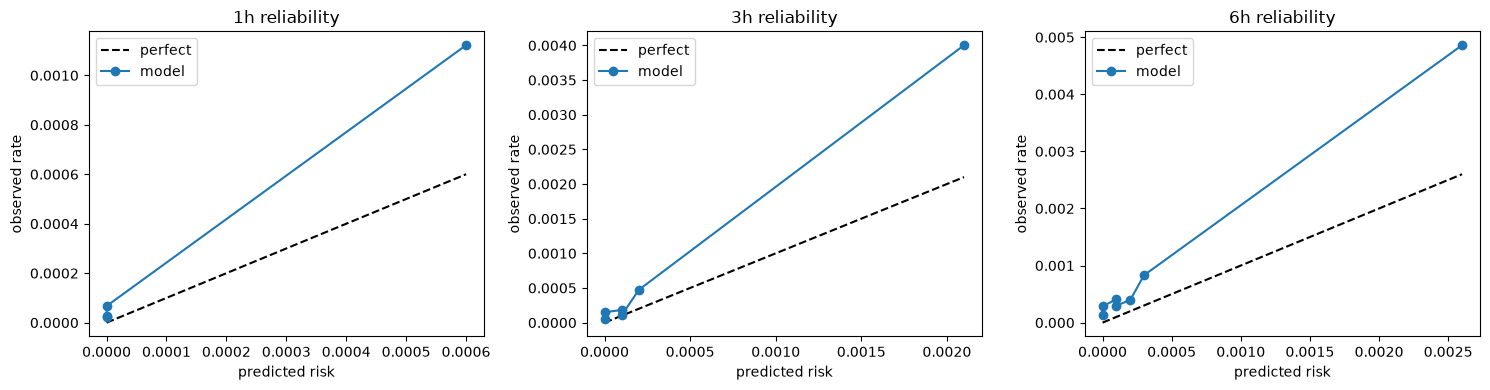

Saved calibrators -> /Users/pritimmondal/Projects/bkk-flood-forecast/models/artifacts/calibrators.joblib


In [8]:
# Reliability diagram: predicted risk against what actually happened.
if calibrators:
    fig, axes = plt.subplots(1, len(calibrators), figsize=(5 * len(calibrators), 4),
                             squeeze=False)
    for ax, (stem, calibrator) in zip(axes[0], calibrators.items()):
        horizon = int(stem.split("_")[-1].rstrip("h"))
        model = load_model(stem)
        label = f"y_ge{PRIMARY}_{horizon}h"
        table = calibration_table(calibrator.predict(model.predict(test)),
                                  test[label].to_numpy(), n_bins=12)
        ax.plot([0, table["mean_predicted"].max()], [0, table["mean_predicted"].max()],
                "k--", label="perfect")
        ax.plot(table["mean_predicted"], table["observed_rate"], "o-", label="model")
        ax.set_xlabel("predicted risk"); ax.set_ylabel("observed rate")
        ax.set_title(f"{horizon}h reliability"); ax.legend()
    plt.tight_layout(); plt.show()

    import joblib
    joblib.dump(calibrators, PATHS.artifacts / "calibrators.joblib")
    print(f"Saved calibrators -> {PATHS.artifacts / 'calibrators.joblib'}")

**Reading a reliability diagram.** Points on the dashed line mean the stated risk is
the real risk. Points below it mean the model overstates danger; points above mean it
understates it. Understating is the worse failure here, and it is the one to check first.

## 5. Where the misses are — per-station analysis

Errors are almost never spread evenly. Usually a handful of stations produce most of them,
and they usually have a physical explanation that no amount of tuning will fix. Finding
them turns "the model is 55% accurate" into a specific, actionable list.

In [9]:
horizon = 1
label = f"y_ge{PRIMARY}_{horizon}h"
stem = f"clf_ge{PRIMARY}_{horizon}h"

try:
    model = load_model(stem)
    scored = test.copy()
    scored["score"] = hybrid_score(model.predict(test), persistence_score(test, PRIMARY))
    scored["pred"] = (scored["score"] >= (model.threshold or 0.5)).astype(int)

    by_station = per_station_breakdown(scored, label, "pred")
    print(f"Stations producing the most missed floods ({horizon}h, {PRIMARY} cm):")
    display(by_station.head(15))

    total_fn = by_station["fn"].sum()
    top10 = by_station.head(10)["fn"].sum()
    print(f"\nTop 10 stations account for {top10}/{total_fn} misses "
          f"({top10 / max(total_fn, 1):.0%}) across {len(by_station)} stations.")
except Exception as exc:
    print(f"Train and save the models first (notebook 04). {exc}")

Stations producing the most missed floods (1h, 15 cm):


,station_code,positives,tp,fn,fp,recall,precision,f2,false_negative_rate,n_rows,alarms,tn,f1,false_positive_rate,specificity,alarms_per_hit,csi
0,FL.SMI.01,64,43,21,1047,0.6719,0.0394,0.1597,0.3281,35040,1090,33929,0.0745,0.029935,0.9701,25.35,0.0387
1,FL.BNA.04,49,32,17,94,0.6531,0.2540,0.4969,0.3469,35040,126,34897,0.3657,0.002686,0.9973,3.94,0.2238
2,FL.STN.03,33,20,13,132,0.6061,0.1316,0.3521,0.3939,35040,152,34875,0.2162,0.003771,0.9962,7.60,0.1212
3,FL.CTC.04,45,33,12,416,0.7333,0.0735,0.2623,0.2667,35040,449,34579,0.1336,0.011887,0.9881,13.61,0.0716
4,FL.DDG.02,42,30,12,266,0.7143,0.1014,0.3233,0.2857,35040,296,34732,0.1775,0.007600,0.9924,9.87,0.0974
5,FL.DDG.01,25,14,11,196,0.5600,0.0667,0.2258,0.4400,35040,210,34819,0.1191,0.005598,0.9944,15.00,0.0633
6,FL.LSI.02,31,21,10,127,0.6774,0.1419,0.3860,0.3226,35040,148,34882,0.2346,0.003628,0.9964,7.05,0.1329
7,FL.RTW.08,27,17,10,25,0.6296,0.4048,0.5667,0.3704,35040,42,34988,0.4928,0.000714,0.9993,2.47,0.3269
8,FL.BKM.01,41,33,8,159,0.8049,0.1719,0.4635,0.1951,35040,192,34840,0.2833,0.004543,0.9955,5.82,0.1650
9,FL.SLG.03,33,25,8,415,0.7576,0.0568,0.2185,0.2424,35040,440,34592,0.1057,0.011855,0.9881,17.60,0.0558



Top 10 stations account for 122/265 misses (46%) across 100 stations.


In [10]:
# The same view for false alarms — the ones that erode operator trust.
if "by_station" in dir():
    noisy = by_station.sort_values("fp", ascending=False).head(10)
    print("Stations producing the most false alarms:")
    display(noisy[["station_code", "fp", "tp", "precision", "positives"]])
    print("A station with many false alarms and almost no real events is usually a "
          "faulty sensor rather than a modelling problem. Check it against the quality "
          "scorecard from notebook 01 before touching the model.")

Stations producing the most false alarms:


,station_code,fp,tp,precision,positives
45,FL.PWT.02,1441,20,0.0137,20
0,FL.SMI.01,1047,43,0.0394,64
48,FL.LSI.04,1017,5,0.0049,5
3,FL.CTC.04,416,33,0.0735,45
9,FL.SLG.03,415,25,0.0568,33
20,FL.RTW.09,366,17,0.0444,22
37,FL.BKN.01,307,2,0.0065,5
39,FL.RTW.10,290,6,0.0203,8
40,FL.BKE.02,281,4,0.0140,6
4,FL.DDG.02,266,30,0.1014,42


A station with many false alarms and almost no real events is usually a faulty sensor rather than a modelling problem. Check it against the quality scorecard from notebook 01 before touching the model.


## 6. Individual cases — read the actual mistakes

Aggregate metrics tell you how much you are wrong. Reading individual failures tells you
*why*, and that is what changes what you build next.

In [11]:
if "scored" in dir():
    context = [c for c in ["fl_depth_now", "rain_rf1hr_mean", "rain_rf3hr_mean",
                           "water_rising_share", "rain_fcst_3h"] if c in scored.columns]

    print("=== The most confident misses (model was sure it was safe) ===")
    misses = extract_cases(scored, label, "pred", "score", kind="fn",
                           top_n=10, context_cols=context)
    display(misses)

    print("\n=== The loudest false alarms ===")
    alarms = extract_cases(scored, label, "pred", "score", kind="fp",
                           top_n=10, context_cols=context)
    display(alarms)

=== The most confident misses (model was sure it was safe) ===


,station_code,site_timestamp,y_ge15_1h,pred,score,fl_depth_now,rain_rf1hr_mean,rain_rf3hr_mean,water_rising_share,rain_fcst_3h
0,FL.WTN.01,2025-02-08 13:30:00,1,0,2.620746e-12,NaN,0.0,0.0,0.066667,0.0
1,FL.WTN.01,2025-02-08 13:15:00,1,0,3.137655e-12,NaN,0.0,0.0,0.060000,0.0
2,FL.WTN.01,2025-02-08 13:00:00,1,0,4.615168e-12,NaN,0.0,0.0,0.050000,0.0
3,FL.PYT.07,2025-11-13 01:15:00,1,0,5.196155e-12,0.0,0.0,0.0,0.080000,15.9
4,FL.PYT.07,2025-11-13 01:30:00,1,0,8.147623e-12,0.0,0.0,0.0,0.123333,15.9
5,FL.PYT.04,2025-11-13 01:15:00,1,0,1.146026e-11,0.0,0.0,0.0,0.080000,15.9
6,FL.PYT.01,2025-11-13 01:30:00,1,0,1.336931e-11,0.0,0.0,0.0,0.123333,15.9
7,FL.RTW.04,2025-11-13 01:45:00,1,0,3.109910e-11,0.0,1.0,1.0,0.220000,10.4
8,FL.WTN.01,2025-02-08 13:45:00,1,0,3.136272e-11,0.0,0.0,0.0,0.070000,0.0
9,FL.PYT.05,2025-11-13 01:15:00,1,0,3.758740e-11,0.0,0.0,0.0,0.080000,15.9



=== The loudest false alarms ===


,station_code,site_timestamp,y_ge15_1h,pred,score,fl_depth_now,rain_rf1hr_mean,rain_rf3hr_mean,water_rising_share,rain_fcst_3h
0,FL.PPS.01,2025-05-10 18:15:00,0,1,1.0,18.5,68.000000,68.000000,0.756667,15.4
1,FL.WTL.01,2025-05-10 18:15:00,0,1,1.0,20.4,80.500000,80.500000,0.756667,12.4
2,FL.PYT.04,2025-11-13 02:45:00,0,1,1.0,17.0,72.500000,73.500000,0.410000,13.1
3,FL.RTW.07,2025-11-13 03:15:00,0,1,1.0,15.9,34.750000,89.500000,0.456667,0.1
4,FL.BKM.01,2025-08-25 12:30:00,0,1,1.0,15.1,0.000000,0.000000,0.053333,10.6
5,FL.PWT.02,2025-05-16 16:15:00,0,1,1.0,16.1,0.333333,25.000000,0.103333,0.0
6,FL.BKN.01,2025-11-13 03:15:00,0,1,1.0,15.4,61.000000,69.500000,0.456667,0.2
7,FL.LSI.04,2025-06-05 21:45:00,0,1,1.0,15.1,13.250000,13.250000,0.103333,0.0
8,FL.BKM.02,2025-05-10 19:00:00,0,1,1.0,17.0,33.000000,75.000000,0.713333,7.4
9,FL.WTL.04,2025-05-10 21:15:00,0,1,1.0,15.5,3.000000,15.666667,0.120000,1.0


**How to read a miss.** Look at the rain columns. Two very different failures hide in
the same statistic:

* **Rain was falling and we still missed it.** A model problem — the signal was present and
  we did not use it. Worth fixing.
* **No rain anywhere and the water arrived anyway.** Not a model problem. Either the rain
  fell between gauges (the district-average weakness again), or the water came from
  somewhere else entirely — an upstream canal, a pump switching off, a blocked drain. No
  amount of tuning fixes this. It needs radar, canal topology, or pump records.

Sorting the misses into those two buckets is the single most useful hour you can spend on
this project, and it is what turns the evaluation into a data request.

In [12]:
# Sort the misses into those two buckets automatically.
if "misses" in dir() and "rain_rf1hr_mean" in misses.columns:
    rainless = misses["rain_rf1hr_mean"].fillna(0) < 1.0
    print(f"Of the {len(misses)} worst misses:")
    print(f"  {rainless.sum()} happened with essentially no rain recorded nearby")
    print(f"  {(~rainless).sum()} happened while rain was falling")
    print()
    print("The rainless ones point at missing data (radar, canal topology, pumps).")
    print("The rainy ones point at the model and are the ones worth working on.")

Of the 10 worst misses:
  9 happened with essentially no rain recorded nearby
  1 happened while rain was falling

The rainless ones point at missing data (radar, canal topology, pumps).
The rainy ones point at the model and are the ones worth working on.


## 7. Event-level scoring — what an operator experiences

Row-level metrics over-weight long floods: a six-hour event contributes 24 rows, a
20-minute one contributes 1. Operators do not think in rows. They think in events, and in
how much warning they got.

In [13]:
events_path = PATHS.reports / "flood_events_15cm.csv"
if events_path.exists() and "scored" in dir():
    events = pd.read_csv(events_path, parse_dates=["start", "end", "peak_time"])
    test_year = fold.test_year
    test_events = events[events["start"].dt.year == test_year]

    # Named alarm_rows, not alarms: section 6 binds `alarms` to the worst false
    # positives and section 9 writes that variable out as
    # worst_false_positives.csv. Reusing the name here would silently replace
    # those ten diagnostic rows with every firing in the test year.
    alarm_rows = scored[scored["pred"] == 1][["station_code", "site_timestamp"]]
    scores = event_scores(test_events, alarm_rows, horizon_h=horizon,
                          tolerance_min=CFG["forecast"]["event_match_tolerance_min"])

    print(f"Event-level results for {test_year} ({horizon}h model):")
    for key, value in scores.items():
        print(f"  {key:22s} {value}")
    print()
    print(f"In plain terms: of {scores['events']} flood events, we warned about "
          f"{scores['caught']} ({scores['pod']:.0%}), with a median of "
          f"{scores['median_lead_minutes']} minutes of warning.")

Event-level results for 2025 (1h model):
  events                 112
  caught                 111
  missed                 1
  pod                    0.9911
  far                    0.9572
  csi                    0.011
  alarms                 10440
  median_lead_minutes    15.0
  mean_lead_minutes      24.1

In plain terms: of 112 flood events, we warned about 111 (99%), with a median of 15.0 minutes of warning.


**Why event POD usually beats row recall.** A long flood only has to be caught once to
count as caught. That is the right way to score it: an operator who gets one alarm at the
start of a three-hour flood has been warned, even if the model then goes quiet.

**Median lead time is the number to put in front of BMA.** "63% of floods, with a median
25 minutes of warning" is something a duty officer can plan around. "PR-AUC 0.56" is not.

## 8. Depth bands — is the uncertainty honest?

In [14]:
for horizon in HORIZONS:
    try:
        lo = load_model(f"reg_q05_{horizon}h")
        hi = load_model(f"reg_q95_{horizon}h")
    except Exception:
        continue
    truth = test[f"y_maxdepth_{horizon}h"].to_numpy()
    cov = coverage(truth, lo.predict(test), hi.predict(test))
    print(f"  {horizon}h: P05-P95 band contains {cov:.1%} of outcomes (target ~90%)")
    if cov < 0.85:
        print("     -> band is too narrow; the dashboard is understating the worst case")
    elif cov > 0.95:
        print("     -> band is too wide; it will look uninformative to an operator")

  1h: P05-P95 band contains 99.9% of outcomes (target ~90%)
     -> band is too wide; it will look uninformative to an operator


  3h: P05-P95 band contains 99.7% of outcomes (target ~90%)
     -> band is too wide; it will look uninformative to an operator


  6h: P05-P95 band contains 99.6% of outcomes (target ~90%)
     -> band is too wide; it will look uninformative to an operator


## 9. Save everything the report needs

In [15]:
artefacts = {}
if len(folds_df):
    artefacts["fold_summary"] = summarise_folds(
        folds_df.to_dict("records"),
        group_cols=["target", "horizon_h"])
    artefacts["fold_summary"].to_csv(PATHS.reports / "fold_summary.csv", index=False)
if "by_station" in dir():
    by_station.to_csv(PATHS.reports / "station_breakdown.csv", index=False)
if "misses" in dir():
    misses.to_csv(PATHS.reports / "worst_false_negatives.csv", index=False)
if "alarms" in dir():
    alarms.to_csv(PATHS.reports / "worst_false_positives.csv", index=False)

(PATHS.reports / "evaluation_protocol.json").write_text(
    json.dumps(protocol, indent=2, default=str))
print(f"Wrote evaluation outputs -> {PATHS.reports}")
for p in sorted(PATHS.reports.glob("*")):
    print(f"  {p.name}")

Wrote evaluation outputs -> /Users/pritimmondal/Projects/bkk-flood-forecast/docs/reports
  baseline_results.csv
  class_imbalance.csv
  evaluation_protocol.json
  flood_events_15cm.csv
  fold_summary.csv
  lightgbm_fold_results.csv
  onset_results.csv
  station_breakdown.csv
  worst_false_negatives.csv
  worst_false_positives.csv


### The paragraph to put in the report

> Evaluated with rolling-origin cross-validation across four chronological folds
> (2022-2025 as successive test years), with thresholds selected on the validation year and
> frozen before testing. At the 15 cm advisory tier the model achieves recall of R (range
> across years), precision P, and a false-negative rate of F — that is, it misses F of
> flood rows. Decomposed, recall on already-flooded rows is near-total (a persistence rule
> achieves the same), while recall on genuine onset rows is O; the onset specialists in
> notebook 05 raise that figure substantially at short range. At the event level the system
> warns about E% of flood episodes with a median lead time of L minutes.
>
> Skill decays sharply with horizon. At 6 hours the model is close to climatology, because
> every rainfall input is a district average of rain that has already fallen. Radar
> rainfall and archived forecast rainfall are the two inputs most likely to change that.

Next: `08_final_holdout.ipynb`.